In [2]:
import os

os.getcwd()

'C:\\Users\\karun\\OneDrive\\Documents\\soni\\time-series-forecasting'

In [3]:
import os

os.listdir()

['.ipynb_checkpoints',
 'daily-demand-series.csv.csv',
 'time_series_forecasting.ipynb']

In [4]:
df = pd.read_csv("daily-demand-series.csv")

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [5]:
df.columns

Index(['date', 'demand', 'marketing_event', 'holiday'], dtype='str')

In [6]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [7]:
df = df.set_index('date')

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


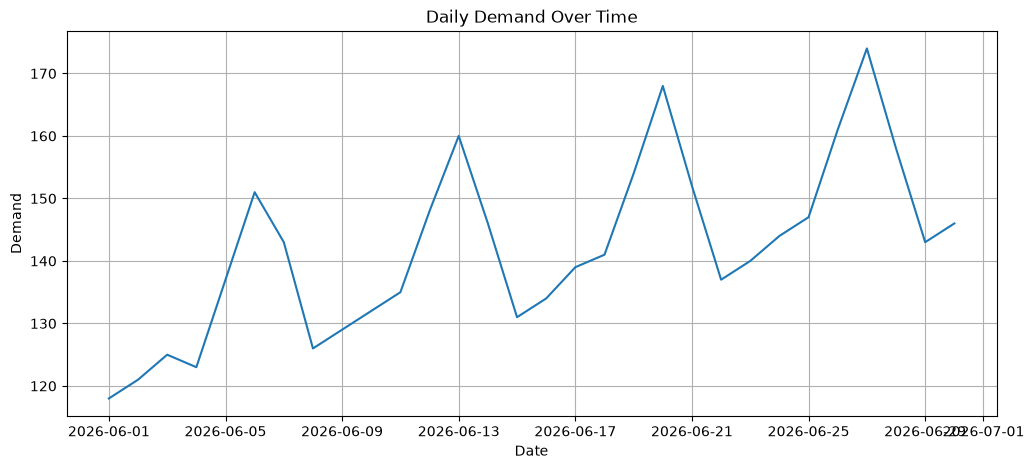

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df['demand'])

plt.title('Daily Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True)

plt.show()

In [9]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 30 entries, 2026-06-01 to 2026-06-30
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   demand           30 non-null     int64
 1   marketing_event  30 non-null     int64
 2   holiday          30 non-null     int64
dtypes: int64(3)
memory usage: 960.0 bytes


In [10]:
df.isnull().sum()

demand             0
marketing_event    0
holiday            0
dtype: int64

In [11]:
df['demand'].describe()

count     30.000000
mean     142.100000
std       13.839848
min      118.000000
25%      132.500000
50%      142.000000
75%      150.250000
max      174.000000
Name: demand, dtype: float64

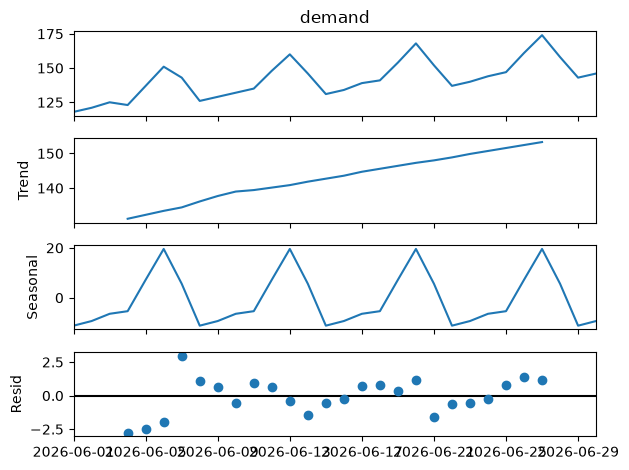

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['demand'],
    model='additive',
    period=7
)

decomposition.plot()
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['demand'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.9038698873856327
p-value: 0.7866953368372346


C:\Users\karun\AppData\Local\Temp\ipykernel_10008\1135269303.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df['demand'])


In [14]:
df['demand_diff'] = df['demand'].diff()

df['demand_diff'].dropna().head()

date
2026-06-02     3.0
2026-06-03     4.0
2026-06-04    -2.0
2026-06-05    14.0
2026-06-06    14.0
Name: demand_diff, dtype: float64

In [15]:
result_diff = adfuller(df['demand_diff'].dropna())

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

ADF Statistic: -2.233624012735417
p-value: 0.19426893706635506


C:\Users\karun\AppData\Local\Temp\ipykernel_10008\1638972550.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(df['demand_diff'].dropna())


In [16]:
df['demand_diff2'] = df['demand_diff'].diff()

df['demand_diff2'].dropna().head()

date
2026-06-03     1.0
2026-06-04    -6.0
2026-06-05    16.0
2026-06-06     0.0
2026-06-07   -22.0
Name: demand_diff2, dtype: float64

In [17]:
result_diff2 = adfuller(df['demand_diff2'].dropna())

print("ADF Statistic:", result_diff2[0])
print("p-value:", result_diff2[1])

ADF Statistic: -15.186988638006413
p-value: 6.085057742439517e-28


C:\Users\karun\AppData\Local\Temp\ipykernel_10008\2145281975.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff2 = adfuller(df['demand_diff2'].dropna())


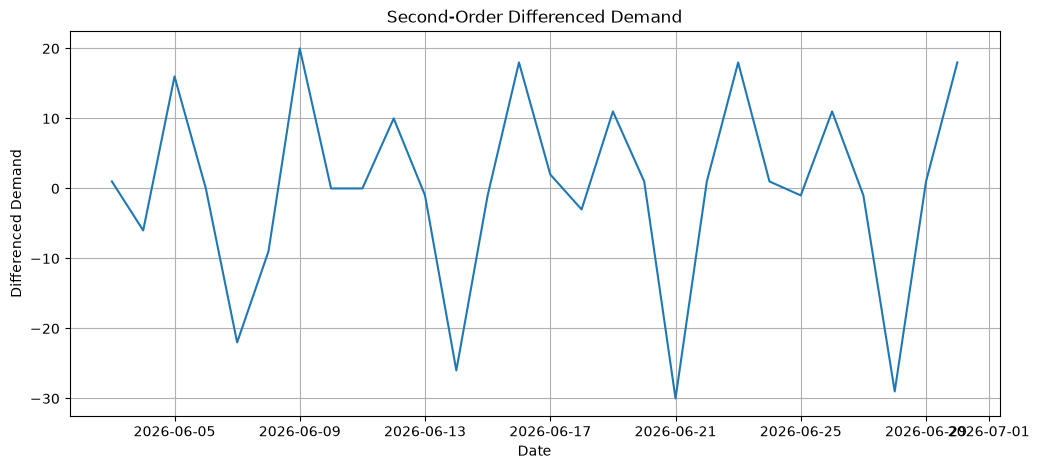

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df['demand_diff2'])

plt.title('Second-Order Differenced Demand')
plt.xlabel('Date')
plt.ylabel('Differenced Demand')
plt.grid(True)

plt.show()

In [19]:
train = df['demand'][:-30]
test = df['demand'][-30:]

print("Training data:", len(train))
print("Test data:", len(test))

Training data: 0
Test data: 30


In [20]:
print("Total rows:", len(df))
print(df.shape)

Total rows: 30
(30, 5)


In [21]:
train = df['demand'][:20]
test = df['demand'][20:]

print("Training data:", len(train))
print("Test data:", len(test))

Training data: 20
Test data: 10


In [22]:
from statsmodels.tsa.arima.model import ARIMA

In [23]:
model = ARIMA(train, order=(1, 2, 1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                   20
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -68.966
Date:                Wed, 09 Sep 2026   AIC                            143.932
Time:                        05:00:09   BIC                            146.603
Sample:                    06-01-2026   HQIC                           144.300
                         - 06-20-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3737      0.929     -0.402      0.688      -2.195       1.447
ma.L1          0.6948      0.654      1.062      0.288      -0.587       1.977
sigma2       123.1463     51.780      2.378      0.0

C:\Users\karun\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\karun\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\karun\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [24]:
forecast = model_fit.forecast(steps=len(test))

print(forecast)

2026-06-21    179.728819
2026-06-22    192.306382
2026-06-23    204.566768
2026-06-24    216.945684
2026-06-25    229.280304
2026-06-26    241.631478
2026-06-27    253.976466
2026-06-28    266.323766
2026-06-29    278.670202
2026-06-30    291.016961
Freq: D, Name: predicted_mean, dtype: float64


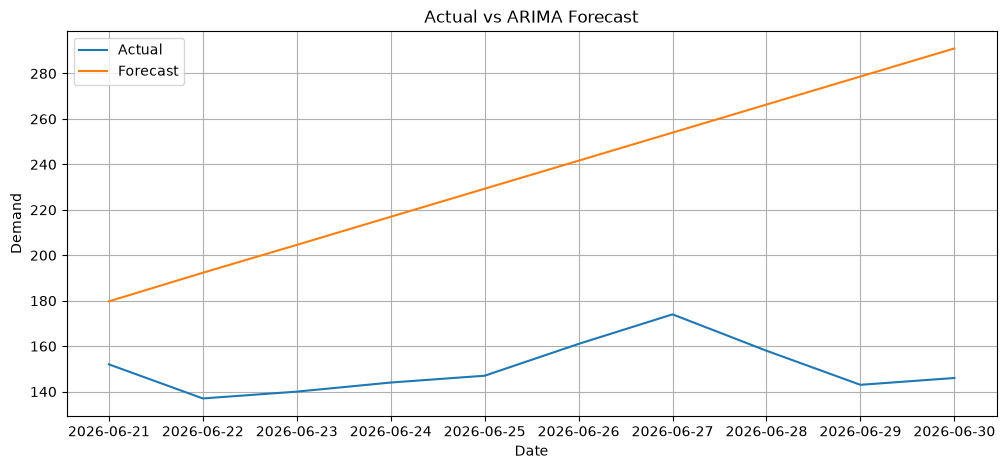

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title('Actual vs ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()

In [26]:
from sklearn.metrics import mean_squared_error

mape = np.mean(np.abs((test - forecast) / test)) * 100
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAPE:", mape)
print("RMSE:", rmse)

MAPE: 57.01665542575751
RMSE: 91.73641767568103


In [27]:
future_forecast = model_fit.forecast(steps=30)

print(future_forecast)

2026-06-21    179.728819
2026-06-22    192.306382
2026-06-23    204.566768
2026-06-24    216.945684
2026-06-25    229.280304
2026-06-26    241.631478
2026-06-27    253.976466
2026-06-28    266.323766
2026-06-29    278.670202
2026-06-30    291.016961
2026-07-01    303.363599
2026-07-02    315.710282
2026-07-03    328.056948
2026-07-04    340.403620
2026-07-05    352.750291
2026-07-06    365.096962
2026-07-07    377.443632
2026-07-08    389.790303
2026-07-09    402.136974
2026-07-10    414.483645
2026-07-11    426.830316
2026-07-12    439.176987
2026-07-13    451.523658
2026-07-14    463.870328
2026-07-15    476.216999
2026-07-16    488.563670
2026-07-17    500.910341
2026-07-18    513.257012
2026-07-19    525.603683
2026-07-20    537.950353
Freq: D, Name: predicted_mean, dtype: float64


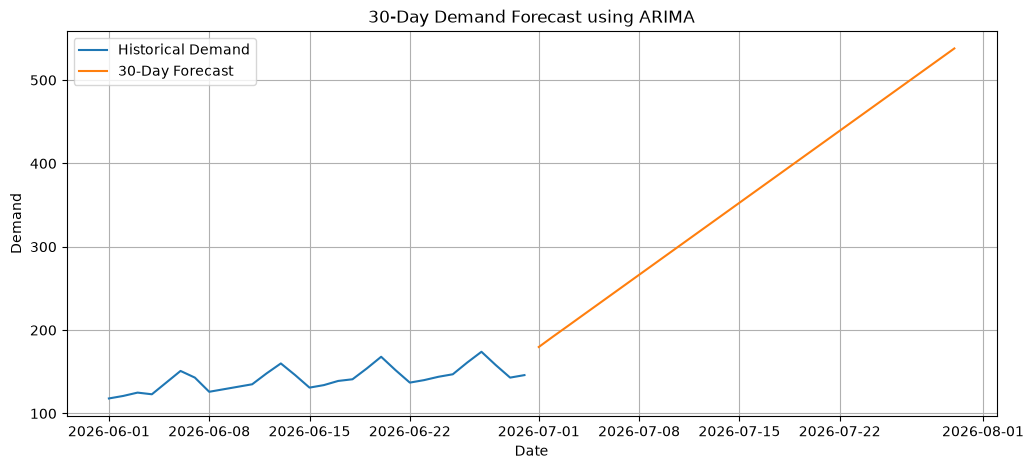

In [28]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

plt.figure(figsize=(12, 5))

plt.plot(df.index, df['demand'], label='Historical Demand')
plt.plot(future_dates, future_forecast, label='30-Day Forecast')

plt.title('30-Day Demand Forecast using ARIMA')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
forecast_table = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Demand': future_forecast.values
})

forecast_table.head(10)

,Date,Forecast_Demand
0,2026-07-01,179.728819
1,2026-07-02,192.306382
2,2026-07-03,204.566768
3,2026-07-04,216.945684
4,2026-07-05,229.280304
5,2026-07-06,241.631478
6,2026-07-07,253.976466
7,2026-07-08,266.323766
8,2026-07-09,278.670202
9,2026-07-10,291.016961


In [30]:
print("===== TIME-SERIES FORECASTING SUMMARY =====")
print("Model: ARIMA(1,2,1)")
print("Training Data:", len(train))
print("Test Data:", len(test))
print("MAPE:", round(mape, 2), "%")
print("RMSE:", round(rmse, 2))
print("Forecast Period: 30 Days")

===== TIME-SERIES FORECASTING SUMMARY =====
Model: ARIMA(1,2,1)
Training Data: 20
Test Data: 10
MAPE: 57.02 %
RMSE: 91.74
Forecast Period: 30 Days
